In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = load_diabetes(as_frame=True)
# Features and target already defined as 'data' and 'target'
X = data.data
y = data.target

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def evaluate_performance(y_true, y_pred, label="Set"):
    print(f"--- {label} Performance ---")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}\n")

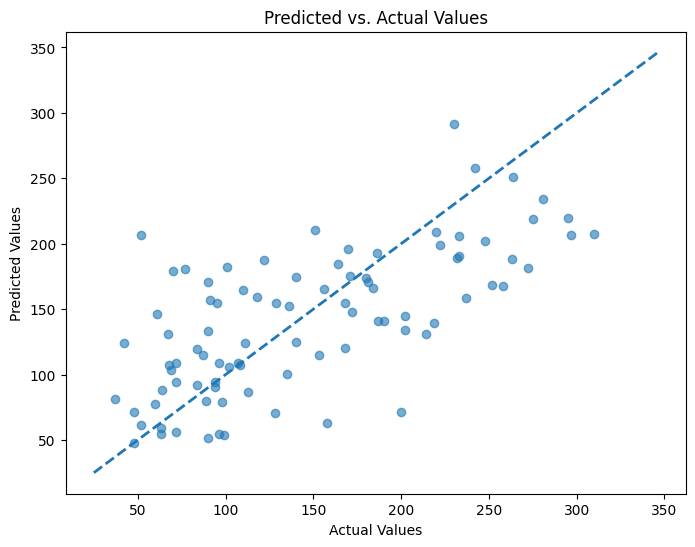

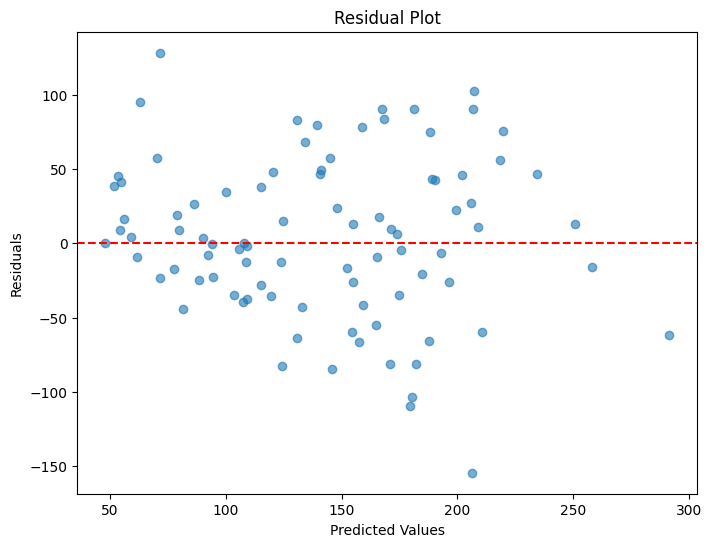

--- Baseline (Mean Predictor) Performance ---
MAE: 64.0065
MSE: 5361.5335
RMSE: 73.2225
R² Score: -0.0120

--- Training Performance ---
MAE: 43.4835
MSE: 2868.5497
RMSE: 53.5588
R² Score: 0.5279

--- Test Performance ---
MAE: 42.7941
MSE: 2900.1936
RMSE: 53.8534
R² Score: 0.4526



In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

baseline_pred = np.full_like(y_test, y_train.mean())

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Predicted vs. Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "--", lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs. Actual Values")
plt.show()

## Residual Plot
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

evaluate_performance(y_test, baseline_pred, label="Baseline (Mean Predictor)")
evaluate_performance(y_train, y_pred_train, label="Training")
evaluate_performance(y_test, y_pred_test, label="Test")

The Baseline results for this dataset indicate that there is a negative variance and that it would be worse than just picking the average values. This metric will not be hard to beat.
The MSE is quite high and idicates large deviations in the data.